In [1]:
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────────
PREPROCESSING_DIR = Path("/kaggle/input/notebooks/adityarajpaul/02-preprocessing/exports")
TRAINING_DIR      = Path("/kaggle/input/notebooks/adityarajpaul/03-model-training/checkpoints")
OUTPUT_DIR        = Path("/kaggle/working/fine_tuning")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = TRAINING_DIR / "initial_epoch_29_valacc_0.9796.h5"

# ── Hyperparameters ────────────────────────────────────────────────────────────
IMAGE_SIZE   = (300, 300)
BATCH_SIZE   = 32
FINE_TUNE_LR = 1e-5
FINE_TUNE_EPOCHS = 20
UNFREEZE_PERCENT = 0.30
NUM_CLASSES  = 38

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))
print("Checkpoint exists:", CHECKPOINT_PATH.exists())

2026-06-08 10:25:23.540789: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780914323.726255      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780914323.787295      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780914324.256194      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780914324.256230      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780914324.256235      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Checkpoint exists: True


In [2]:
with open(PREPROCESSING_DIR / "class_mapping.json") as f:
    class_mapping = json.load(f)

with open(PREPROCESSING_DIR / "class_weights.json") as f:
    class_weights_raw = json.load(f)

with open(PREPROCESSING_DIR / "dataset_splits.json") as f:
    dataset_splits = json.load(f)

class_weights = {int(k): v for k, v in class_weights_raw.items()}

print(f"Classes loaded:      {len(class_mapping)}")
print(f"Train samples:       {len(dataset_splits['paths_train'])}")
print(f"Val samples:         {len(dataset_splits['paths_val'])}")
print(f"Test samples:        {len(dataset_splits['paths_test'])}")
print(f"Class weight range:  {min(class_weights.values()):.4f} – {max(class_weights.values()):.4f}")

Classes loaded:      38
Train samples:       43443
Val samples:         5431
Test samples:        5431
Class weight range:  0.2595 – 9.3708


In [3]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(file_path, label):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)   # [0, 255] range — EfficientNetB3 normalizes internally
    return image, label

augmentation_layer = keras.Sequential([
    keras.layers.RandomFlip("horizontal_and_vertical"),
    keras.layers.RandomRotation(0.2),
    keras.layers.RandomZoom(0.15),
    keras.layers.RandomBrightness(0.15, value_range=(0, 255)),
    keras.layers.RandomContrast(0.15),
], name="augmentation")

def make_dataset(split_key, augment=False):
    paths  = dataset_splits[f"paths_{split_key}"]
    labels = dataset_splits[f"labels_{split_key}"]

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if augment:
        ds = ds.map(lambda x, y: (augmentation_layer(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset("train", augment=True)
val_ds   = make_dataset("val",   augment=False)
test_ds  = make_dataset("test",  augment=False)

print("train_ds:", train_ds)
print("val_ds:  ", val_ds)

I0000 00:00:1780914340.004393      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780914340.010319      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
val_ds:   <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [4]:
def build_model(num_classes):
    base_model = keras.applications.EfficientNetB3(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMAGE_SIZE, 3)
    )
    base_model.trainable = False   # start frozen; we unfreeze selectively below

    inputs = keras.Input(shape=(*IMAGE_SIZE, 3))
    x = base_model(inputs, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dense(256, activation="relu")(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs)

model = build_model(NUM_CLASSES)
model.load_weights(str(CHECKPOINT_PATH))

print("Checkpoint loaded successfully.")
print(f"Total layers in model:     {len(model.layers)}")
print(f"Total layers in base model: {len(model.layers[1].layers)}")

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Checkpoint loaded successfully.
Total layers in model:     7
Total layers in base model: 385


In [5]:
base_model = model.layers[1]   # EfficientNetB3 is the second layer (index 1)

total_base_layers = len(base_model.layers)
unfreeze_from     = int(total_base_layers * (1 - UNFREEZE_PERCENT))

print(f"Base model total layers:  {total_base_layers}")
print(f"Unfreezing from index:    {unfreeze_from}")
print(f"Layers to unfreeze:       {total_base_layers - unfreeze_from}")

base_model.trainable = True   # enable trainability on the whole base first

for layer in base_model.layers[:unfreeze_from]:
    layer.trainable = False   # re-freeze everything before the cutoff

# Verify
trainable_count   = sum(1 for l in base_model.layers if l.trainable)
untrainable_count = sum(1 for l in base_model.layers if not l.trainable)
print(f"\nBase model — trainable layers:   {trainable_count}")
print(f"Base model — frozen layers:      {untrainable_count}")
print(f"\nFirst unfrozen layer: {base_model.layers[unfreeze_from].name}")
print(f"Last unfrozen layer:  {base_model.layers[-1].name}")

Base model total layers:  385
Unfreezing from index:    269
Layers to unfreeze:       116

Base model — trainable layers:   116
Base model — frozen layers:      269

First unfrozen layer: block6a_dwconv
Last unfrozen layer:  top_activation


In [6]:
@tf.keras.utils.register_keras_serializable()
def top3_accuracy(y_true, y_pred):
    return tf.keras.metrics.sparse_top_k_categorical_accuracy(y_true, y_pred, k=3)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy", top3_accuracy]
)

trainable_params     = sum(tf.size(w).numpy() for w in model.trainable_weights)
non_trainable_params = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f"Trainable parameters:     {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")

Trainable parameters:     8,799,780
Non-trainable parameters: 2,393,137


In [7]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=str(OUTPUT_DIR / "finetuned_epoch_{epoch:02d}_valacc_{val_accuracy:.4f}.h5"),
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    mode="max",
    verbose=1
)

early_stopping_cb = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

csv_logger_cb = keras.callbacks.CSVLogger(
    str(OUTPUT_DIR / "fine_tuning_log.csv"),
    append=False
)

callbacks = [checkpoint_cb, early_stopping_cb, reduce_lr_cb, csv_logger_cb]
print("Callbacks configured.")

Callbacks configured.


In [8]:
print("Starting fine-tuning from epoch 30 (continuing from initial training)...")
print(f"Learning rate: {FINE_TUNE_LR}")
print(f"Max additional epochs: {FINE_TUNE_EPOCHS}")
print("-" * 60)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\nFine-tuning complete.")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

Starting fine-tuning from epoch 30 (continuing from initial training)...
Learning rate: 1e-05
Max additional epochs: 20
------------------------------------------------------------
Epoch 1/20


I0000 00:00:1780914373.549578      68 service.cc:152] XLA service 0x7af110005650 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780914373.549630      68 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780914373.549635      68 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780914380.244543      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-08 10:26:33.625608: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-08 10:26:33.782293: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-08 10:26:34.244155: E external/local_xl

1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.7498 - loss: 1.0235 - top3_accuracy: 0.9111

2026-06-08 10:37:50.043879: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-08 10:37:50.191108: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-08 10:37:50.578055: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-08 10:37:50.724930: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-08 10:37:51.551371: E external/local_xla/xla/stream_

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.7499 - loss: 1.0233 - top3_accuracy: 0.9111

...


Epoch 12: finished saving model to /kaggle/working/fine_tuning/finetuned_epoch_12_valacc_0.9843.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 638s 469ms/step - accuracy: 0.9807 - loss: 0.0548 - top3_accuracy: 0.9992 - val_accuracy: 0.9843 - val_loss: 0.0490 - val_top3_accuracy: 0.9993 - learning_rate: 1.0000e-05
Epoch 13/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9826 - loss: 0.0508 - top3_accuracy: 0.9992
Epoch 13: val_accuracy improved from 0.98435 to 0.98619, saving model to /kaggle/working/fine_tuning/finetuned_epoch_13_valacc_0.9862.h5



Epoch 13: finished saving model to /kaggle/working/fine_tuning/finetuned_epoch_13_valacc_0.9862.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 644s 474ms/step - accuracy: 0.9824 - loss: 0.0529 - top3_accuracy: 0.9992 - val_accuracy: 0.9862 - val_loss: 0.0478 - val_top3_accuracy: 0.9991 - learning_rate: 1.0000e-05
Epoch 14/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9824 - loss: 0.0518 - top3_accuracy: 0.9992
Epoch 14: val_accuracy improved from 0.98619 to 0.98748, saving model to /kaggle/working/fine_tuning/finetuned_epoch_14_valacc_0.9875.h5



Epoch 14: finished saving model to /kaggle/working/fine_tuning/finetuned_epoch_14_valacc_0.9875.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 640s 471ms/step - accuracy: 0.9836 - loss: 0.0475 - top3_accuracy: 0.9993 - val_accuracy: 0.9875 - val_loss: 0.0429 - val_top3_accuracy: 0.9993 - learning_rate: 1.0000e-05
Epoch 15/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9838 - loss: 0.0465 - top3_accuracy: 0.9994
Epoch 15: val_accuracy did not improve from 0.98748
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 639s 471ms/step - accuracy: 0.9842 - loss: 0.0444 - top3_accuracy: 0.9994 - val_accuracy: 0.9864 - val_loss: 0.0450 - val_top3_accuracy: 0.9991 - learning_rate: 1.0000e-05
Epoch 16/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9857 - loss: 0.0402 - top3_accuracy: 0.9993
Epoch 16: val_accuracy did not improve from 0.98748
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 640s 471ms/step - accuracy: 0.9856 - loss: 0.0380 - top3_accuracy: 0.9994 - val_accuracy: 0.9871 - val_loss: 0.0418 - val_top3_ac


Epoch 18: finished saving model to /kaggle/working/fine_tuning/finetuned_epoch_18_valacc_0.9893.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 640s 471ms/step - accuracy: 0.9872 - loss: 0.0348 - top3_accuracy: 0.9995 - val_accuracy: 0.9893 - val_loss: 0.0360 - val_top3_accuracy: 0.9996 - learning_rate: 1.0000e-05
Epoch 19/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9879 - loss: 0.0334 - top3_accuracy: 0.9996
Epoch 19: val_accuracy improved from 0.98932 to 0.99043, saving model to /kaggle/working/fine_tuning/finetuned_epoch_19_valacc_0.9904.h5



Epoch 19: finished saving model to /kaggle/working/fine_tuning/finetuned_epoch_19_valacc_0.9904.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 641s 472ms/step - accuracy: 0.9881 - loss: 0.0316 - top3_accuracy: 0.9996 - val_accuracy: 0.9904 - val_loss: 0.0336 - val_top3_accuracy: 0.9996 - learning_rate: 1.0000e-05
Epoch 20/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9895 - loss: 0.0319 - top3_accuracy: 0.9997
Epoch 20: val_accuracy did not improve from 0.99043
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 640s 471ms/step - accuracy: 0.9897 - loss: 0.0307 - top3_accuracy: 0.9997 - val_accuracy: 0.9904 - val_loss: 0.0320 - val_top3_accuracy: 0.9996 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 19.

Fine-tuning complete.
Best val_accuracy: 0.9904


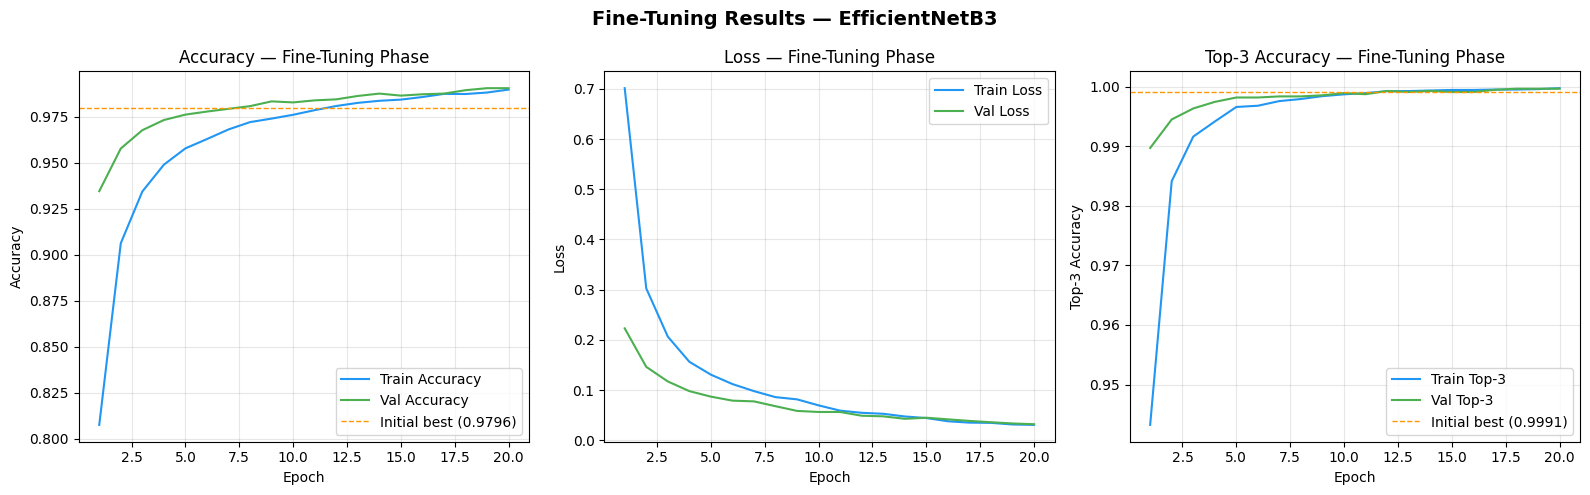

Plot saved.


In [9]:
def plot_fine_tuning_results(history):
    epochs = range(1, len(history.history["accuracy"]) + 1)

    fig = plt.figure(figsize=(16, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig)

    # ── Accuracy ──────────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(epochs, history.history["accuracy"],     label="Train Accuracy", color="#2196F3")
    ax1.plot(epochs, history.history["val_accuracy"], label="Val Accuracy",   color="#4CAF50")
    ax1.axhline(y=0.9796, color="#FF9800", linestyle="--", linewidth=1, label="Initial best (0.9796)")
    ax1.set_title("Accuracy — Fine-Tuning Phase")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ── Loss ──────────────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(epochs, history.history["loss"],     label="Train Loss", color="#2196F3")
    ax2.plot(epochs, history.history["val_loss"], label="Val Loss",   color="#4CAF50")
    ax2.set_title("Loss — Fine-Tuning Phase")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # ── Top-3 Accuracy ────────────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2])
    ax3.plot(epochs, history.history["top3_accuracy"],     label="Train Top-3", color="#2196F3")
    ax3.plot(epochs, history.history["val_top3_accuracy"], label="Val Top-3",   color="#4CAF50")
    ax3.axhline(y=0.9991, color="#FF9800", linestyle="--", linewidth=1, label="Initial best (0.9991)")
    ax3.set_title("Top-3 Accuracy — Fine-Tuning Phase")
    ax3.set_xlabel("Epoch")
    ax3.set_ylabel("Top-3 Accuracy")
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.suptitle("Fine-Tuning Results — EfficientNetB3", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / "fine_tuning_curves.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved.")

plot_fine_tuning_results(history)

In [10]:
# ── Final metrics ─────────────────────────────────────────────────────────────
best_val_acc    = max(history.history["val_accuracy"])
best_val_top3   = max(history.history["val_top3_accuracy"])
epochs_run      = len(history.history["accuracy"])
stopped_early   = epochs_run < FINE_TUNE_EPOCHS

print("=" * 60)
print("FINE-TUNING SUMMARY")
print("=" * 60)
print(f"Epochs run:              {epochs_run} / {FINE_TUNE_EPOCHS}")
print(f"Early stopping triggered:{stopped_early}")
print(f"Initial val_accuracy:    0.9796")
print(f"Best fine-tuned val_acc: {best_val_acc:.4f}")
print(f"Improvement:             {(best_val_acc - 0.9796)*100:+.3f}%")
print(f"Best val top-3 accuracy: {best_val_top3:.4f}")
print()

# ── List saved outputs ────────────────────────────────────────────────────────
print("Files saved to /kaggle/working/fine_tuning/:")
for f in sorted(OUTPUT_DIR.iterdir()):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name:<55} {size_mb:.2f} MB")

print()
print("NEXT STEP: Commit this notebook as Version 1 before closing.")
print("Outputs will be available at:")
print("/kaggle/input/notebooks/adityarajpaul/04-fine-tuning/fine_tuning/")

FINE-TUNING SUMMARY
Epochs run:              20 / 20
Early stopping triggered:False
Initial val_accuracy:    0.9796
Best fine-tuned val_acc: 0.9904
Improvement:             +1.083%
Best val top-3 accuracy: 0.9996

Files saved to /kaggle/working/fine_tuning/:
  fine_tuning_curves.png                                  0.14 MB
  fine_tuning_log.csv                                     0.00 MB
  finetuned_epoch_01_valacc_0.9345.h5                     110.64 MB
  finetuned_epoch_02_valacc_0.9577.h5                     110.64 MB
  finetuned_epoch_03_valacc_0.9676.h5                     110.64 MB
  finetuned_epoch_04_valacc_0.9731.h5                     110.64 MB
  finetuned_epoch_05_valacc_0.9761.h5                     110.64 MB
  finetuned_epoch_06_valacc_0.9777.h5                     110.64 MB
  finetuned_epoch_07_valacc_0.9792.h5                     110.64 MB
  finetuned_epoch_08_valacc_0.9807.h5                     110.64 MB
  finetuned_epoch_09_valacc_0.9832.h5                     110.64 

In [11]:
best_h5 = max(
    [f for f in OUTPUT_DIR.iterdir() if f.suffix == ".h5"],
    key=lambda f: float(f.name.split("valacc_")[1].replace(".h5", ""))
)
print(f"Best checkpoint found: {best_h5.name}")

keras_save_path = OUTPUT_DIR / "finetuned_best.keras"
model.save(str(keras_save_path))

weights_save_path = OUTPUT_DIR / "finetuned_best.weights.h5"
model.save_weights(str(weights_save_path))

Best checkpoint found: finetuned_epoch_19_valacc_0.9904.h5


In [12]:
best_h5_name = max(
    [f.name for f in OUTPUT_DIR.iterdir() if f.suffix == ".h5" 
     and "weights" not in f.name],
    key=lambda name: float(name.split("valacc_")[1].replace(".h5", ""))
)

keep = {best_h5_name, "finetuned_best.keras", 
        "finetuned_best.weights.h5", 
        "fine_tuning_curves.png", 
        "fine_tuning_log.csv"}

for f in OUTPUT_DIR.iterdir():
    if f.name not in keep:
        os.remove(f)

In [13]:
for f in sorted(OUTPUT_DIR.iterdir()):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"{f.name:<55} {size_mb:.2f} MB")

fine_tuning_curves.png                                  0.14 MB
fine_tuning_log.csv                                     0.00 MB
finetuned_best.keras                                    111.21 MB
finetuned_best.weights.h5                               110.86 MB
finetuned_epoch_19_valacc_0.9904.h5                     110.64 MB
